<a href="https://colab.research.google.com/github/lakshuu-jay/Projects/blob/main/MealRecommendationEngine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 267M/267M [00:11<00:00, 23.5MB/s]

Extracting files...


User Ratings:
                                       name  rating
0  arriba baked winter squash mexican style       5
1           a bit different breakfast pizza       4
2                  all in the kitchen chili       5
3                         alouette potatoes       3

Matched Meals:
   recipe_id                                        name  rating
0     137739  arriba   baked winter squash mexican style       5
1      31490            a bit different  breakfast pizza       4
2     112140                   all in the kitchen  chili       5
3      59389                          alouette  potatoes       3


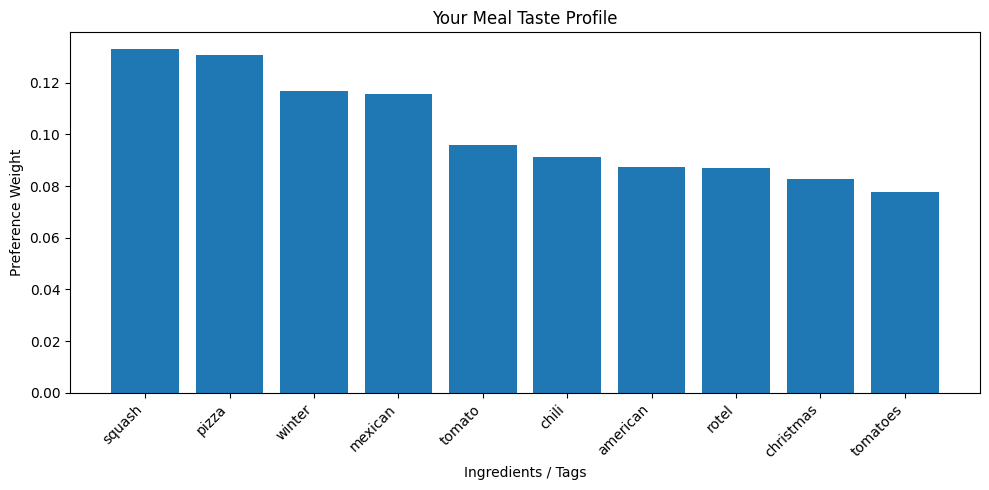


Top 10 Meal Recommendations:
                                                    name  minutes  \
47436                                              chili      135   
19179                                  bbq chicken pizza       30   
48150                                   chilly day chili       55   
3036                      alamo tamale supper  crock pot      370   
34515             can t noboby make chili like ya moma s       75   
23170              betty crocker s family favorite chili      260   
20521             beef pizza casserole  with pizza crust       55   
32419  butternut squash and potatoes with rosemary  s...      200   
11654                                awesome potato stew      490   
23369                         big bend texas style chili       75   

       n_ingredients  similarity_score  
47436              8          0.477757  
19179             11          0.471491  
48150             11          0.470537  
3036               7          0.468126  
34515

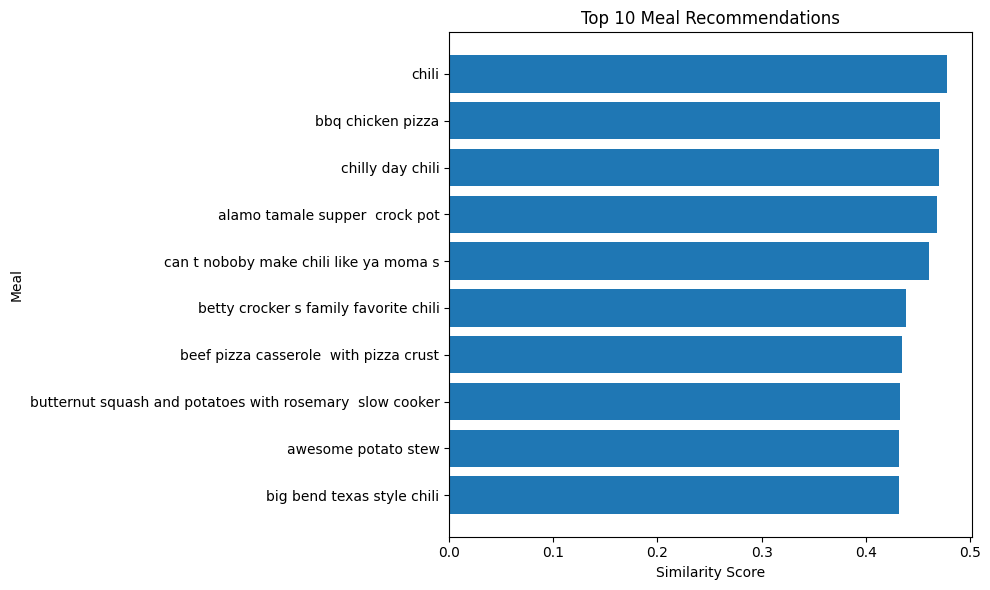

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

path = kagglehub.dataset_download(
    "shuyangli94/food-com-recipes-and-user-interactions"
)
recipes_df = pd.read_csv(Path(path) / "RAW_recipes.csv")

recipes_df = recipes_df[
    ["id", "name", "minutes", "tags", "ingredients", "n_ingredients"]
].dropna(subset=["id", "name", "tags", "ingredients"])

recipes_df = recipes_df.drop_duplicates("id")
recipes_df = recipes_df.rename(columns={"id": "recipe_id"})
recipes_df = recipes_df.reset_index(drop=True)

def clean_name(name):
    return " ".join(str(name).lower().split())

recipes_df["name_key"] = recipes_df["name"].apply(clean_name)

def convert_list(value):
    try:
        return ast.literal_eval(value)
    except (ValueError, SyntaxError, TypeError):
        return []

recipes_df["tags"] = recipes_df["tags"].apply(convert_list)
recipes_df["ingredients"] = recipes_df["ingredients"].apply(convert_list)
recipes_df["content"] = recipes_df.apply(
    lambda row: " ".join(row["tags"] + row["ingredients"]), axis=1
)

recipes_sample = recipes_df.head(50000).copy().reset_index(drop=True)

vectorizer = TfidfVectorizer(stop_words="english", max_features=1500)
recipe_matrix = vectorizer.fit_transform(recipes_sample["content"])

user_input = pd.DataFrame([
    {"name": "arriba baked winter squash mexican style", "rating": 5},
    {"name": "a bit different breakfast pizza", "rating": 4},
    {"name": "all in the kitchen chili", "rating": 5},
    {"name": "alouette potatoes", "rating": 3}
])
user_input["name_key"] = user_input["name"].apply(clean_name)

print("User Ratings:")
print(user_input[["name", "rating"]])

recipe_lookup = recipes_sample[
    ["recipe_id", "name", "name_key"]
].reset_index().drop_duplicates("name_key")

rated_meals = recipe_lookup.merge(
    user_input[["name_key", "rating"]], on="name_key", how="inner"
)

print("\nMatched Meals:")
print(rated_meals[["recipe_id", "name", "rating"]])

rated_indices = rated_meals["index"].to_numpy()
rated_matrix = recipe_matrix[rated_indices]
ratings = rated_meals["rating"].to_numpy(dtype=float)

weighted_matrix = rated_matrix.multiply(ratings.reshape(-1, 1))
user_profile = weighted_matrix.sum(axis=0)
user_profile = np.asarray(user_profile).reshape(1, -1)
user_profile = user_profile / ratings.sum()

features = np.array(vectorizer.get_feature_names_out())
weights = user_profile.flatten()
top_indices = weights.argsort()[-10:][::-1]

top_features = features[top_indices]
top_weights = weights[top_indices]

plt.figure(figsize=(10, 5))
plt.bar(top_features, top_weights)
plt.title("Your Meal Taste Profile")
plt.xlabel("Ingredients / Tags")
plt.ylabel("Preference Weight")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

similarity_scores = cosine_similarity(
    recipe_matrix, user_profile
).flatten()
recipes_sample["similarity_score"] = similarity_scores

recommendations = recipes_sample[
    ~recipes_sample["recipe_id"].isin(rated_meals["recipe_id"])
].copy()

recommendations = recommendations.sort_values(
    "similarity_score", ascending=False
)
top10 = recommendations.head(10)

print("\nTop 10 Meal Recommendations:")
print(top10[
    ["name", "minutes", "n_ingredients", "similarity_score"]
])
plot_data = top10.sort_values("similarity_score")

plt.figure(figsize=(10, 6))
plt.barh(plot_data["name"], plot_data["similarity_score"])
plt.title("Top 10 Meal Recommendations")
plt.xlabel("Similarity Score")
plt.ylabel("Meal")
plt.tight_layout()
plt.show()
